# Классификация Oxford Pets

Обучим сеть для классификации исходного датасета [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Загрузите датасет с Kaggle.

In [1]:
# Получаем датасет
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

# Распаковываем архивы
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

# Посмотрим, сколько файлов скачалось в папку images
!ls -1 images/*.jpg | wc -l

--2026-04-16 08:41:23--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-16 08:41:24--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  26.2MB/s    in 28s     

2026-04-16 08:41:53 (26.7 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-04-16 08:41:53--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [25]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights, vgg19, VGG19_Weights, resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
import seaborn as sns

Всего уникальных пород: 37
Пример маппинга (первые 5 классов):
0 : Abyssinian
1 : Bengal
2 : Birman
3 : Bombay
4 : British_Shorthair


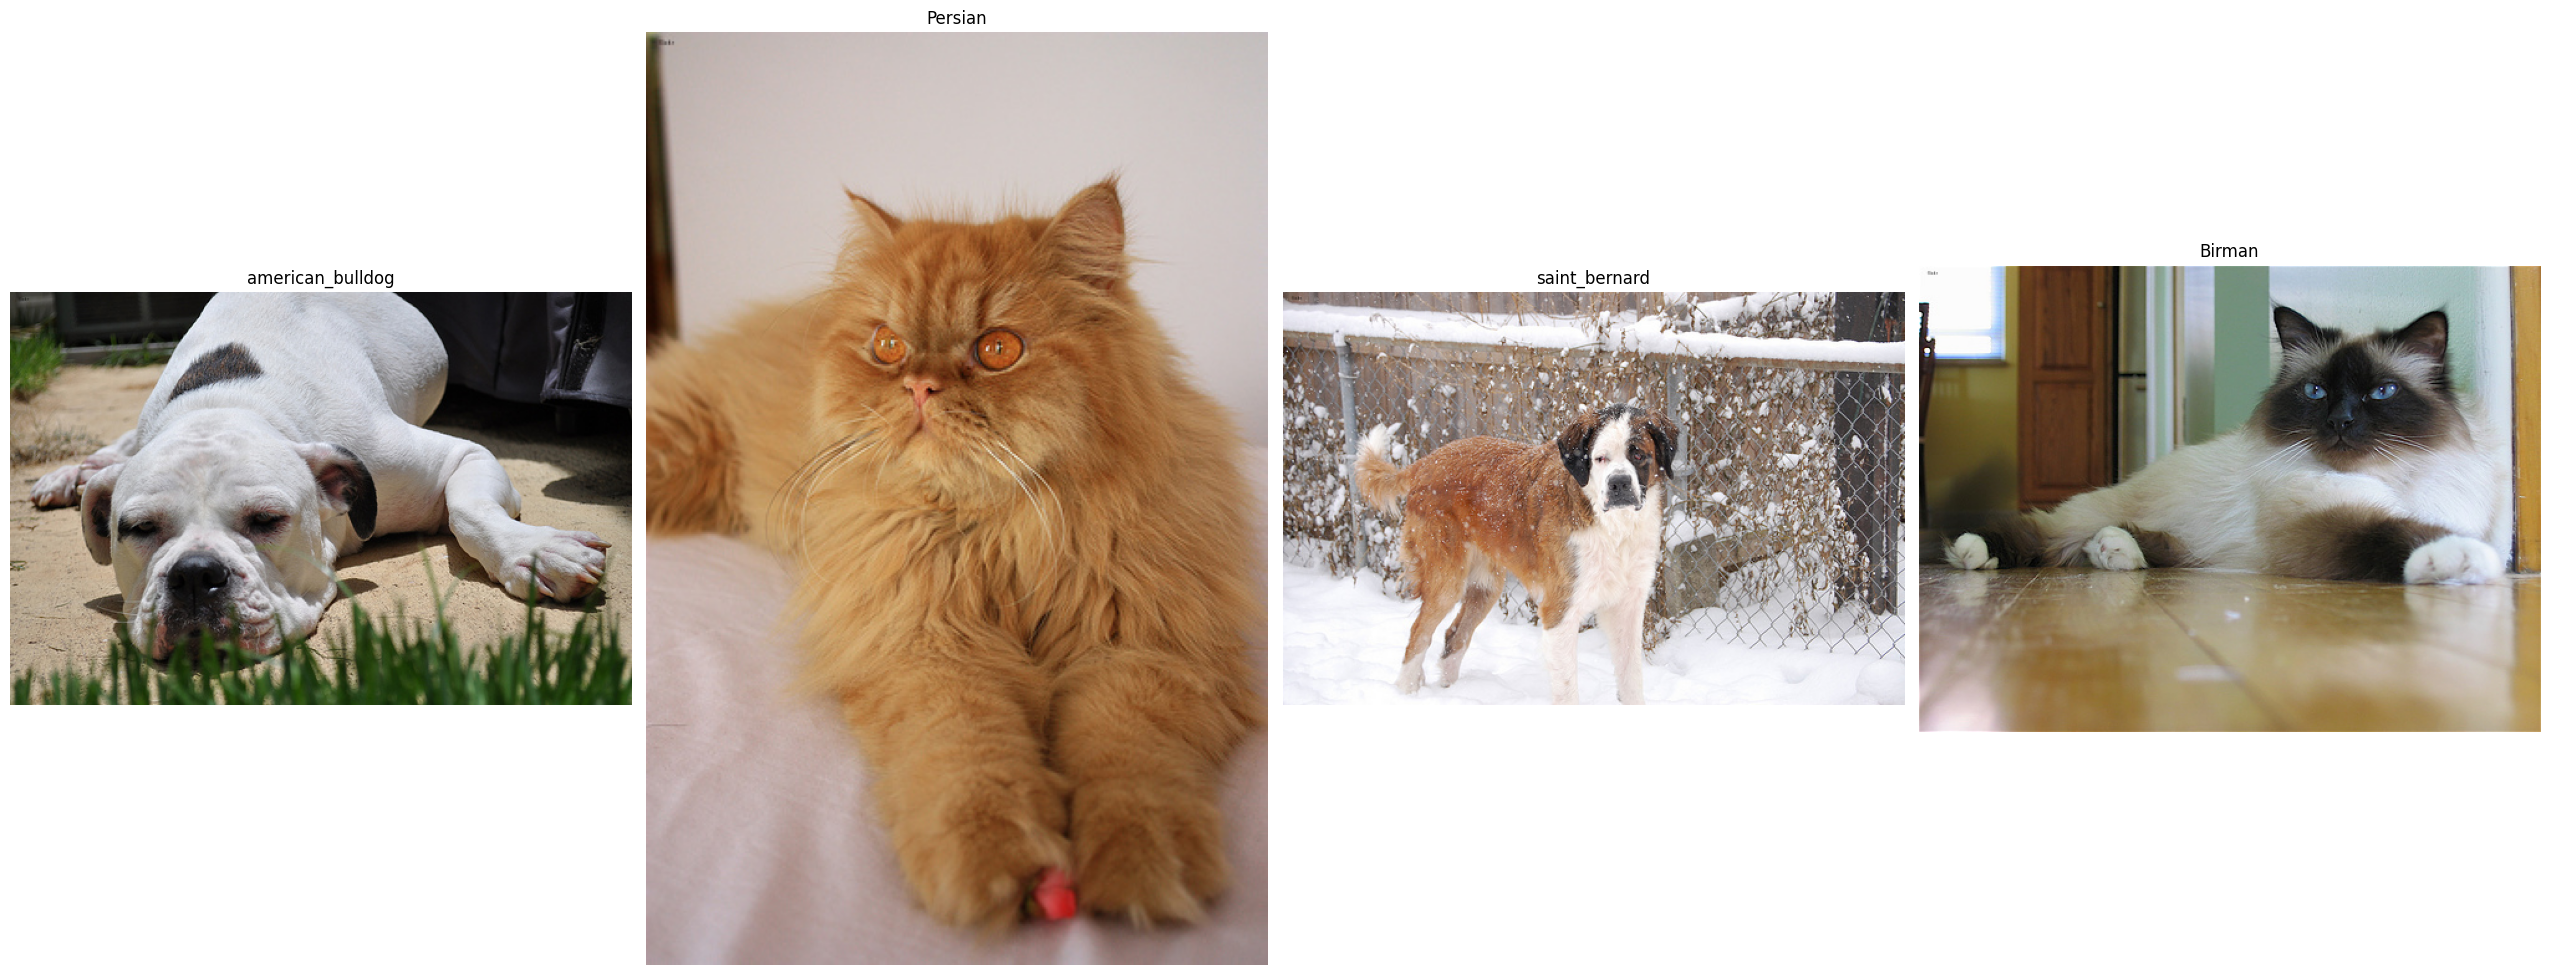

In [3]:
def display_images(l, titles=None, fontsize=12):
    n = len(l)
    fig, ax = plt.subplots(1, n)
    for i, im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i], fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches() * n)
    plt.tight_layout()
    plt.show()

# Получаем список всех картинок (игнорируем системные файлы, если они есть)
image_dir = 'images'
all_files =[f for f in os.listdir(image_dir) if f.endswith('.jpg')]

# Извлекаем породы и создаем словари
labels =[]
for file in all_files:
    parts = file.split("_")
    breed = "_".join(parts[:-1])
    labels.append(breed)

# Получаем отсортированный список уникальных пород
unique_breeds = sorted(list(set(labels)))
print(f"Всего уникальных пород: {len(unique_breeds)}")

# Словари для перевода "Порода -> Число" и "Число -> Порода"
class_to_idx = {breed: idx for idx, breed in enumerate(unique_breeds)}
idx_to_class = {idx: breed for idx, breed in enumerate(unique_breeds)}

print("Пример маппинга (первые 5 классов):")
for i in range(5):
    print(f"{i} : {idx_to_class[i]}")

# Визуализируем 4 случайные картинки
random_files = random.sample(all_files, 4)
images_to_show = []
titles_to_show =[]

for file in random_files:
    img_path = os.path.join(image_dir, file)
    # Открываем картинку через PIL и конвертируем в RGB
    # (в датасете могут быть ч/б картинки, а моделям нужны 3 канала)
    img = Image.open(img_path).convert('RGB')
    images_to_show.append(img)

    breed = "_".join(file.split("_")[:-1])
    titles_to_show.append(breed)

display_images(images_to_show, titles=titles_to_show)

Видно, что картинки разного размера, так что для обучения будем их ресайзить

In [9]:
# Делаем как в первом пунке, разбиваем на 80/20 со stratify по лейблам, чтобы везде нормальное соотношение было

train_files, test_files, train_labels, test_labels = train_test_split(all_files, labels,
                                                                      test_size=0.2, random_state=42, stratify=labels)

print(f"Картинок для обучения: {len(train_files)}")
print(f"Картинок для теста: {len(test_files)}")

# Подготовим трансформсы для всех картинок. Знаем, что сетки были обучены на датасете ImageNet, применим такую же нормализацию

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


# Будем вырезать кусок картинки 224x224, такого же размера, как и в ImageNet на предобученных сетках
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(), # Докинем отрожение по диагонали
    transforms.ToTensor(),
    normalize
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

class PetsDataset(Dataset):
  def __init__(self, file_list, image_dir, transform=None):
    self.file_list = file_list
    self.image_dir = image_dir
    self.transform = transform

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    file_name = self.file_list[idx]
    img_path = os.path.join(self.image_dir, file_name)

    image = Image.open(img_path).convert('RGB')

    breed = "_".join(file_name.split("_")[:-1])
    label = class_to_idx[breed]

    if self.transform:
      image = self.transform(image)

    return image, label

# Сдклаем датасеты и даталоадеры

train_dataset = PetsDataset(train_files, image_dir, transform=train_transforms)
test_dataset = PetsDataset(test_files, image_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=2)

# Проверим, что лоадер работает
images_batch, labels_batch = next(iter(train_loader))
print(f"Формат батча картинок: {images_batch.shape}")
print(f"Формат батча меток: {labels_batch.shape}")

Картинок для обучения: 5912
Картинок для теста: 1478
Формат батча картинок: torch.Size([32, 3, 224, 224])
Формат батча меток: torch.Size([32])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}\n")

Используем устройство: cuda



# Функции для обучения моделек, теперь без tqdm

In [11]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func, device):
    running_loss = 0.0
    correct_top1 = 0
    total = 0

    model.train()

    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outp = model(X_batch)
        loss = loss_func(outp, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outp, 1)
        correct_top1 += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_top1 = 100 * correct_top1 / total

    return epoch_loss, epoch_top1

def eval_one_epoch(model, val_dataloader, loss_func, device, mode='multiclass'):
    running_loss = 0.0
    correct_top1 = 0
    correct_top3 = 0
    correct_top5 = 0
    total = 0

    model.eval()

    for X_batch, y_batch in val_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        with torch.no_grad():
            outp = model(X_batch)
            loss = loss_func(outp, y_batch)

            _, preds = torch.max(outp, 1)
            correct_top1 += (preds == y_batch).sum().item()

            if mode == 'multiclass':
                _, top3_preds = outp.topk(3, dim=1)
                correct_top3 += (top3_preds == y_batch.view(-1, 1)).sum().item()

                _, top5_preds = outp.topk(5, dim=1)
                correct_top5 += (top5_preds == y_batch.view(-1, 1)).sum().item()

            running_loss += loss.item() * X_batch.size(0)
            total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_top1 = 100 * correct_top1 / total

    if mode == 'multiclass':
        epoch_top3 = 100 * correct_top3 / total
        epoch_top5 = 100 * correct_top5 / total
        return epoch_loss, epoch_top1, epoch_top3, epoch_top5
    else:
        return epoch_loss, epoch_top1

def train_func(model, num_epochs, dataloaders, optimizer, loss_func, device, scheduler=None, mode='multiclass'):
    if mode == 'multiclass':
        history = {'train_loss':[], 'val_loss': [], 'train_top1': [], 'val_top1':[], 'val_top3':[], 'val_top5':[]}
    else:
        history = {'train_loss':[], 'val_loss':[], 'train_top1': [], 'val_top1':[]}

    best_model_weights = copy.deepcopy(model.state_dict())
    best_top1 = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        train_loss, train_top1 = fit_one_epoch(model, dataloaders['train'], optimizer, loss_func, device)

        if mode == 'multiclass':
            val_loss, val_top1, val_top3, val_top5 = eval_one_epoch(model, dataloaders['val'], loss_func, device, mode)
        else:
            val_loss, val_top1 = eval_one_epoch(model, dataloaders['val'], loss_func, device, mode)

        if scheduler:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_top1'].append(train_top1)
        history['val_top1'].append(val_top1)

        if mode == 'multiclass':
            history['val_top3'].append(val_top3)
            history['val_top5'].append(val_top5)

        print(f"Train Loss: {train_loss:.4f} | Train Top-1: {train_top1:.2f}%")

        if mode == 'multiclass':
            print(f"Val Loss:   {val_loss:.4f} | Val Top-1:   {val_top1:.2f}% | Val Top-3: {val_top3:.2f}% | Val Top-5: {val_top5:.2f}%")
        else:
            print(f"Val Loss:   {val_loss:.4f} | Val Top-1:   {val_top1:.2f}%")

        if val_top1 > best_top1:
            best_top1 = val_top1
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"--> Saved new best model with Val Top-1: {best_top1:.2f}%\n")
        else:
            print("\n")

    print(f"Training complete. Loading best model weights (Top-1: {best_top1:.2f}%)")
    model.load_state_dict(best_model_weights)
    return model, history

# Первой моделькой будет VGG-16

In [13]:
model_vgg = vgg16(weights=VGG16_Weights.DEFAULT)

for param in model_vgg.parameters():
    param.requires_grad = False

print(model_vgg)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 63.8MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Заморозив все слои измени последний так, чтобы он выводил нам не 1000 классов, как в ImageNet, а 37 классов наших пород

In [14]:
in_features = model_vgg.classifier[6].in_features
model_vgg.classifier[6] = nn.Linear(in_features, 37)

model_vgg = model_vgg.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(model_vgg.classifier.parameters(), lr=0.001)

dataloaders = {
    'train': train_loader,
    'val': test_loader
}

print("Начинаем обучение VGG-16...")
model_vgg, history_vgg = train_func(
    model=model_vgg,
    num_epochs=5,
    dataloaders=dataloaders,
    optimizer=optimizer_vgg,
    loss_func=criterion,
    device=device,
    mode='multiclass'
)

Начинаем обучение VGG-16...
Epoch 1/5
Train Loss: 0.8899 | Train Top-1: 73.21%
Val Loss:   0.3221 | Val Top-1:   88.63% | Val Top-3: 98.85% | Val Top-5: 99.59%
--> Saved new best model with Val Top-1: 88.63%

Epoch 2/5
Train Loss: 0.6202 | Train Top-1: 80.01%
Val Loss:   0.2636 | Val Top-1:   91.34% | Val Top-3: 98.99% | Val Top-5: 99.86%
--> Saved new best model with Val Top-1: 91.34%

Epoch 3/5
Train Loss: 0.5740 | Train Top-1: 82.27%
Val Loss:   0.2693 | Val Top-1:   91.41% | Val Top-3: 99.32% | Val Top-5: 99.73%
--> Saved new best model with Val Top-1: 91.41%

Epoch 4/5
Train Loss: 0.6028 | Train Top-1: 81.78%
Val Loss:   0.2514 | Val Top-1:   91.47% | Val Top-3: 99.39% | Val Top-5: 99.80%
--> Saved new best model with Val Top-1: 91.47%

Epoch 5/5
Train Loss: 0.5807 | Train Top-1: 81.82%
Val Loss:   0.2768 | Val Top-1:   91.07% | Val Top-3: 99.32% | Val Top-5: 99.80%


Training complete. Loading best model weights (Top-1: 91.47%)


Очень неплохие результаты, глянем что следующая выведет

# VGG-19

In [17]:
model_vgg = vgg19(weights=VGG19_Weights.DEFAULT)

for param in model_vgg.parameters():
    param.requires_grad = False

print(model_vgg)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 83.7MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [18]:
in_features = model_vgg.classifier[6].in_features
model_vgg.classifier[6] = nn.Linear(in_features, 37)

model_vgg = model_vgg.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(model_vgg.classifier.parameters(), lr=0.001)

dataloaders = {
    'train': train_loader,
    'val': test_loader
}

print("Начинаем обучение VGG-19...")
model_vgg, history_vgg = train_func(
    model=model_vgg,
    num_epochs=5,
    dataloaders=dataloaders,
    optimizer=optimizer_vgg,
    loss_func=criterion,
    device=device,
    mode='multiclass'
)

Начинаем обучение VGG-19...
Epoch 1/5
Train Loss: 0.8655 | Train Top-1: 73.87%
Val Loss:   0.2967 | Val Top-1:   89.92% | Val Top-3: 98.58% | Val Top-5: 99.80%
--> Saved new best model with Val Top-1: 89.92%

Epoch 2/5
Train Loss: 0.6131 | Train Top-1: 80.94%
Val Loss:   0.2973 | Val Top-1:   89.78% | Val Top-3: 98.71% | Val Top-5: 99.66%


Epoch 3/5
Train Loss: 0.6126 | Train Top-1: 81.31%
Val Loss:   0.2740 | Val Top-1:   91.14% | Val Top-3: 98.92% | Val Top-5: 99.73%
--> Saved new best model with Val Top-1: 91.14%

Epoch 4/5
Train Loss: 0.5679 | Train Top-1: 82.63%
Val Loss:   0.2392 | Val Top-1:   91.95% | Val Top-3: 99.05% | Val Top-5: 99.73%
--> Saved new best model with Val Top-1: 91.95%

Epoch 5/5
Train Loss: 0.5688 | Train Top-1: 82.75%
Val Loss:   0.2552 | Val Top-1:   90.93% | Val Top-3: 99.19% | Val Top-5: 99.73%


Training complete. Loading best model weights (Top-1: 91.95%)


Видно, что точность чуть повысилась. Неплохо!

# Теперь перейдем к ResNet-50

In [21]:
model_resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

for param in model_resnet.parameters():
  param.requires_grad = False

print(model_resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, 37)

model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.fc.parameters(), lr=0.001)

dataloaders = {
    'train': train_loader,
    'val': test_loader
}

print("Начинаем обучение на ResNet-50")
model_resnet, history_resnet = train_func(
    model=model_resnet,
    num_epochs=5,
    dataloaders=dataloaders,
    optimizer=optimizer,
    loss_func=criterion,
    device=device,
    mode='multiclass'
)

Начинаем обучение на ResNet-50
Epoch 1/5
Train Loss: 1.8382 | Train Top-1: 62.80%
Val Loss:   0.7239 | Val Top-1:   89.72% | Val Top-3: 98.17% | Val Top-5: 99.26%
--> Saved new best model with Val Top-1: 89.72%

Epoch 2/5
Train Loss: 0.8478 | Train Top-1: 80.29%
Val Loss:   0.4443 | Val Top-1:   91.54% | Val Top-3: 98.58% | Val Top-5: 99.39%
--> Saved new best model with Val Top-1: 91.54%

Epoch 3/5
Train Loss: 0.6920 | Train Top-1: 81.95%
Val Loss:   0.3422 | Val Top-1:   92.08% | Val Top-3: 98.92% | Val Top-5: 99.66%
--> Saved new best model with Val Top-1: 92.08%

Epoch 4/5
Train Loss: 0.6155 | Train Top-1: 83.12%
Val Loss:   0.2984 | Val Top-1:   92.69% | Val Top-3: 99.12% | Val Top-5: 99.66%
--> Saved new best model with Val Top-1: 92.69%

Epoch 5/5
Train Loss: 0.5739 | Train Top-1: 84.22%
Val Loss:   0.2716 | Val Top-1:   92.56% | Val Top-3: 99.39% | Val Top-5: 99.73%


Training complete. Loading best model weights (Top-1: 92.69%)


Видим в итоге, что ResNet всех уделал со своими 92.69%. Значит для всего следующего берем его

# Считаем точность двоичной классификации модельнкой ResNet

In [24]:
# Создаем тензор-словарь для перевода 37 пород в 2 класса (0 = Собака, 1 = Кошка)
breed_to_binary = torch.zeros(37, dtype=torch.long).to(device)

# Заметим прикол по названиям животных - Породы кошек с Большой буквы, пород собак - с маленькой
print("Разметка классов:")
cats_count, dogs_count = 0, 0
for idx, breed in idx_to_class.items():
    if breed[0].isupper(): # Если с заглавной буквы - Кошка
        breed_to_binary[idx] = 1
        cats_count += 1
    else:                  # Иначе - Собака
        breed_to_binary[idx] = 0
        dogs_count += 1

print(f"Кошек: {cats_count} пород, Собак: {dogs_count} пород.\n")

# Функция для подсчета бинарной точности
def eval_binary_accuracy(model, dataloader, device, binary_mapping):
    model.eval()
    correct_binary = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Получаем предсказания 37 классов
            outp = model(X_batch)
            _, preds = torch.max(outp, 1)

            # переводим 37 классов в 2 класса
            preds_binary = binary_mapping[preds]
            y_binary = binary_mapping[y_batch]

            # Считаем совпадения
            correct_binary += (preds_binary == y_binary).sum().item()
            total += y_batch.size(0)

    binary_acc = 100 * correct_binary / total
    return binary_acc

# Вычисляем и выводим результат
binary_accuracy = eval_binary_accuracy(model_resnet, test_loader, device, breed_to_binary)
print(f"Точность бинарной классификации 'Кошки против Собак': {binary_accuracy:.2f}%")

Разметка классов:
Кошек: 12 пород, Собак: 25 пород.

Точность бинарной классификации 'Кошки против Собак': 99.32%


Неплохая точность!

# Построим confusion matrix и выведем все accuracy

По модельке ResNet accuracy:

Top-1:   92.69%

Top-3:   99.12%

Top-5:   99.66%


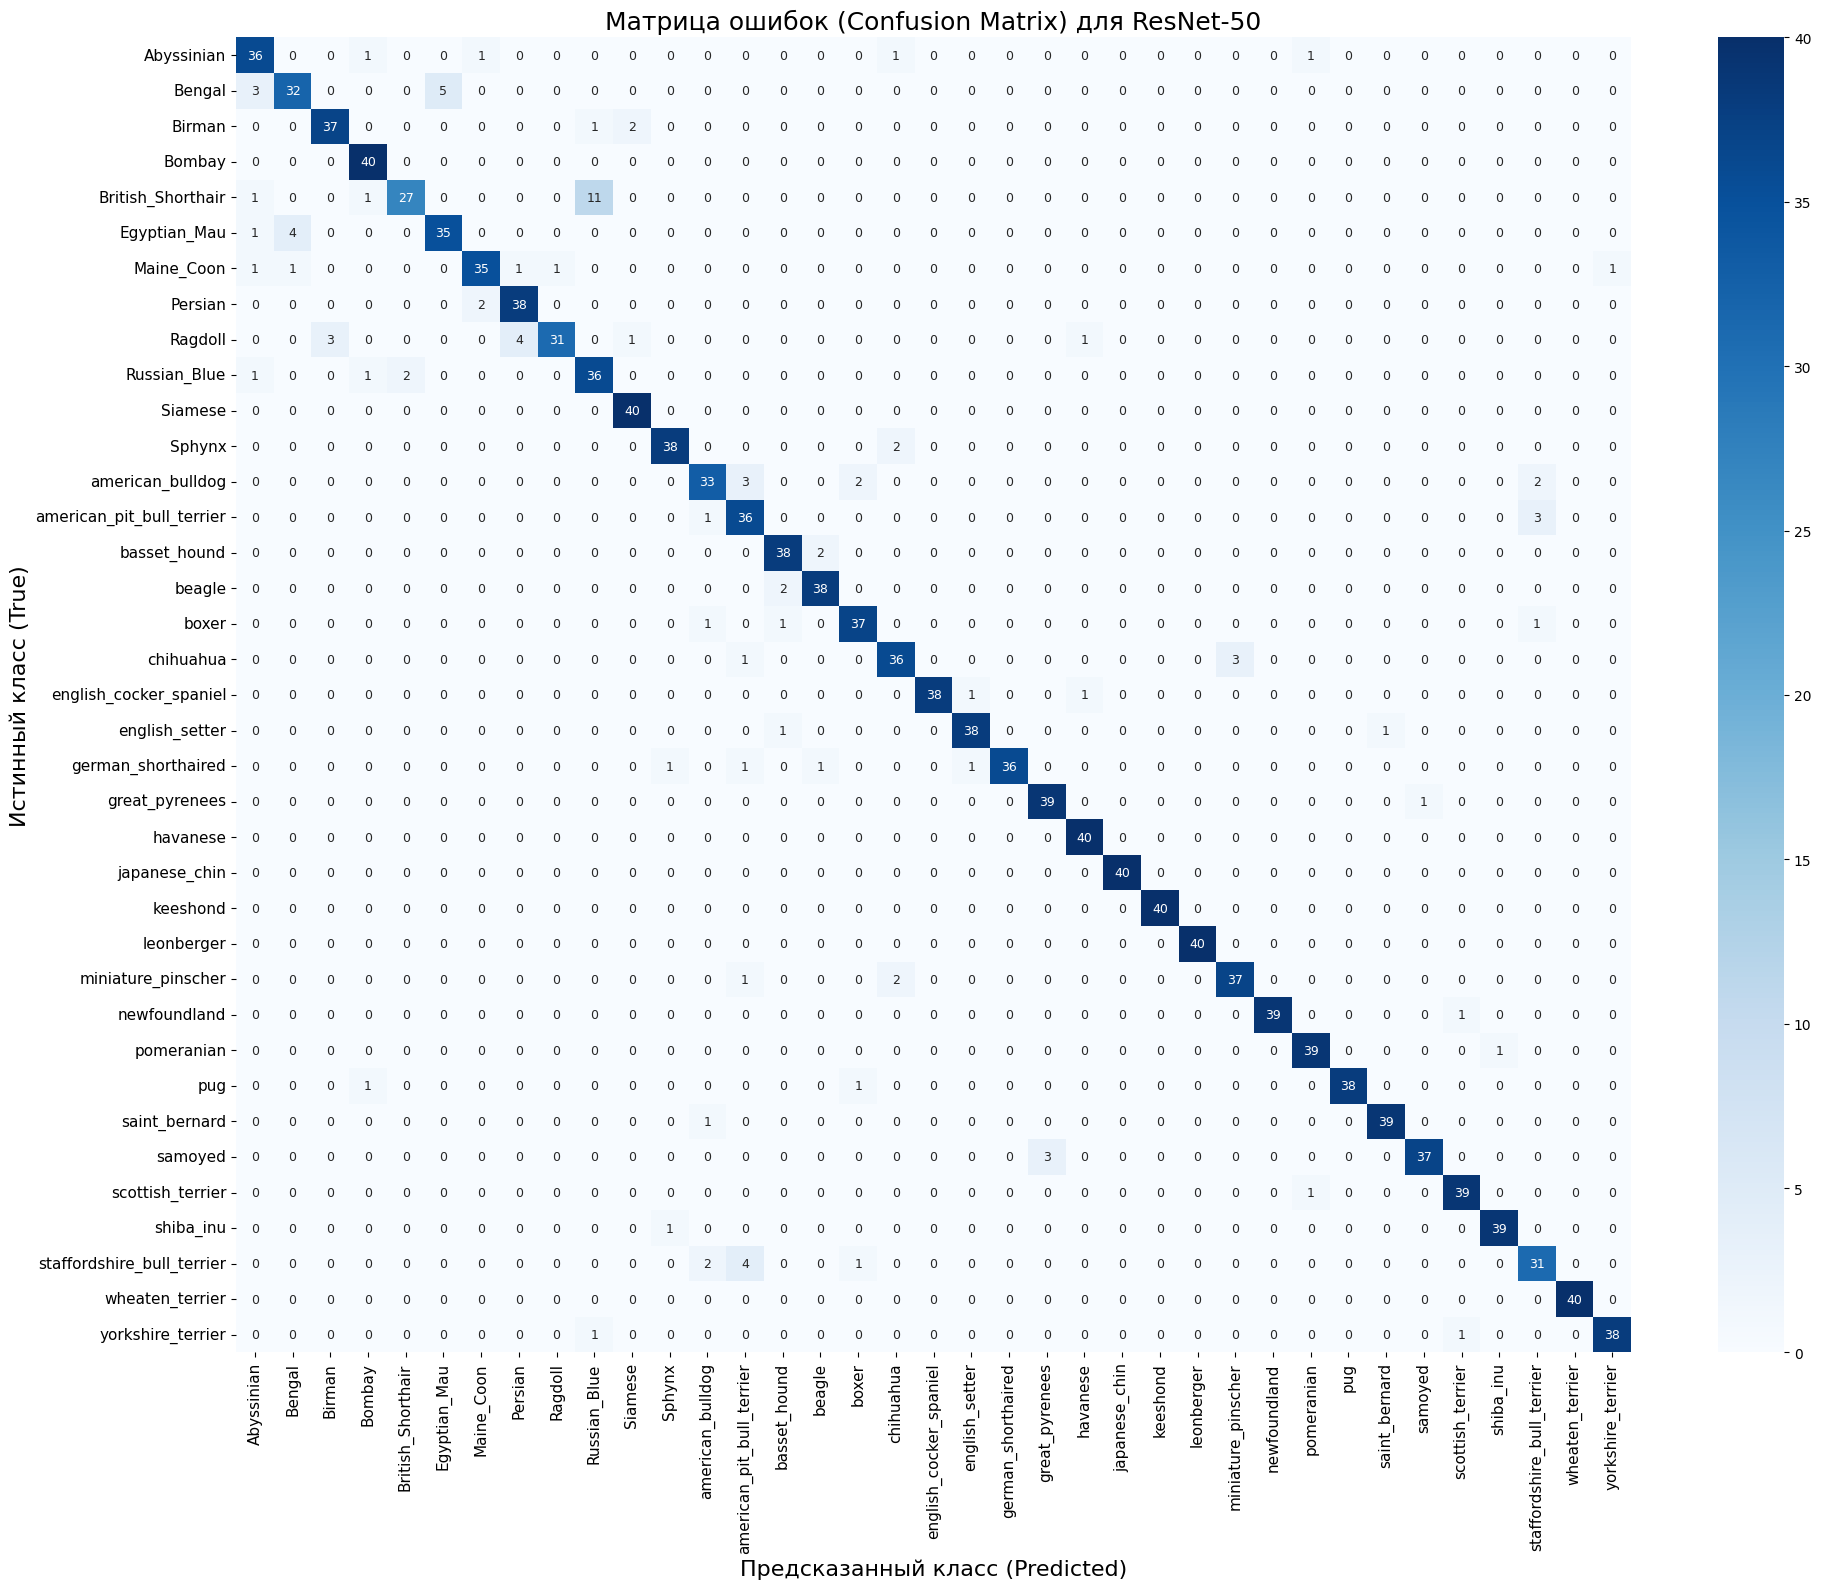

In [26]:
all_preds = []
all_labels =[]

model_resnet.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outp = model_resnet(X_batch)
        _, preds = torch.max(outp, 1)

        # Переносим данные обратно на процессор (CPU) и сохраняем в списки
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Вычисляем матрицу ошибок
cm = confusion_matrix(all_labels, all_preds)

# Получаем список названий пород в правильном порядке (от 0 до 36)
class_names = [idx_to_class[i] for i in range(37)]

# Рисуем красивый график с помощью seaborn
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 9}) # размер шрифта цифр внутри ячеек

plt.xlabel('Предсказанный класс (Predicted)', fontsize=16)
plt.ylabel('Истинный класс (True)', fontsize=16)
plt.title('Матрица ошибок (Confusion Matrix) для ResNet-50', fontsize=18)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Отличная матрица с очень хорошими результатами! Кошек с собаками мы практически никогда не путаем, проблемы начинажтся внутри видов животных. Например, путаются British Shorthair и Russian Blue целых 11 раз. Обе породы кошек имеют сплошной серый (голубой) окрас и схожее телосложение.

# Grad-cam

Я делал все через торч, поэтому и тут тоже буду через него

In [27]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=098419294c053ada89e66db3b59e92140ecf1b78e2654e79b16ee02a83ae410f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Выбранные классы для анализа: ['Persian', 'Bengal', 'chihuahua', 'beagle', 'basset_hound']


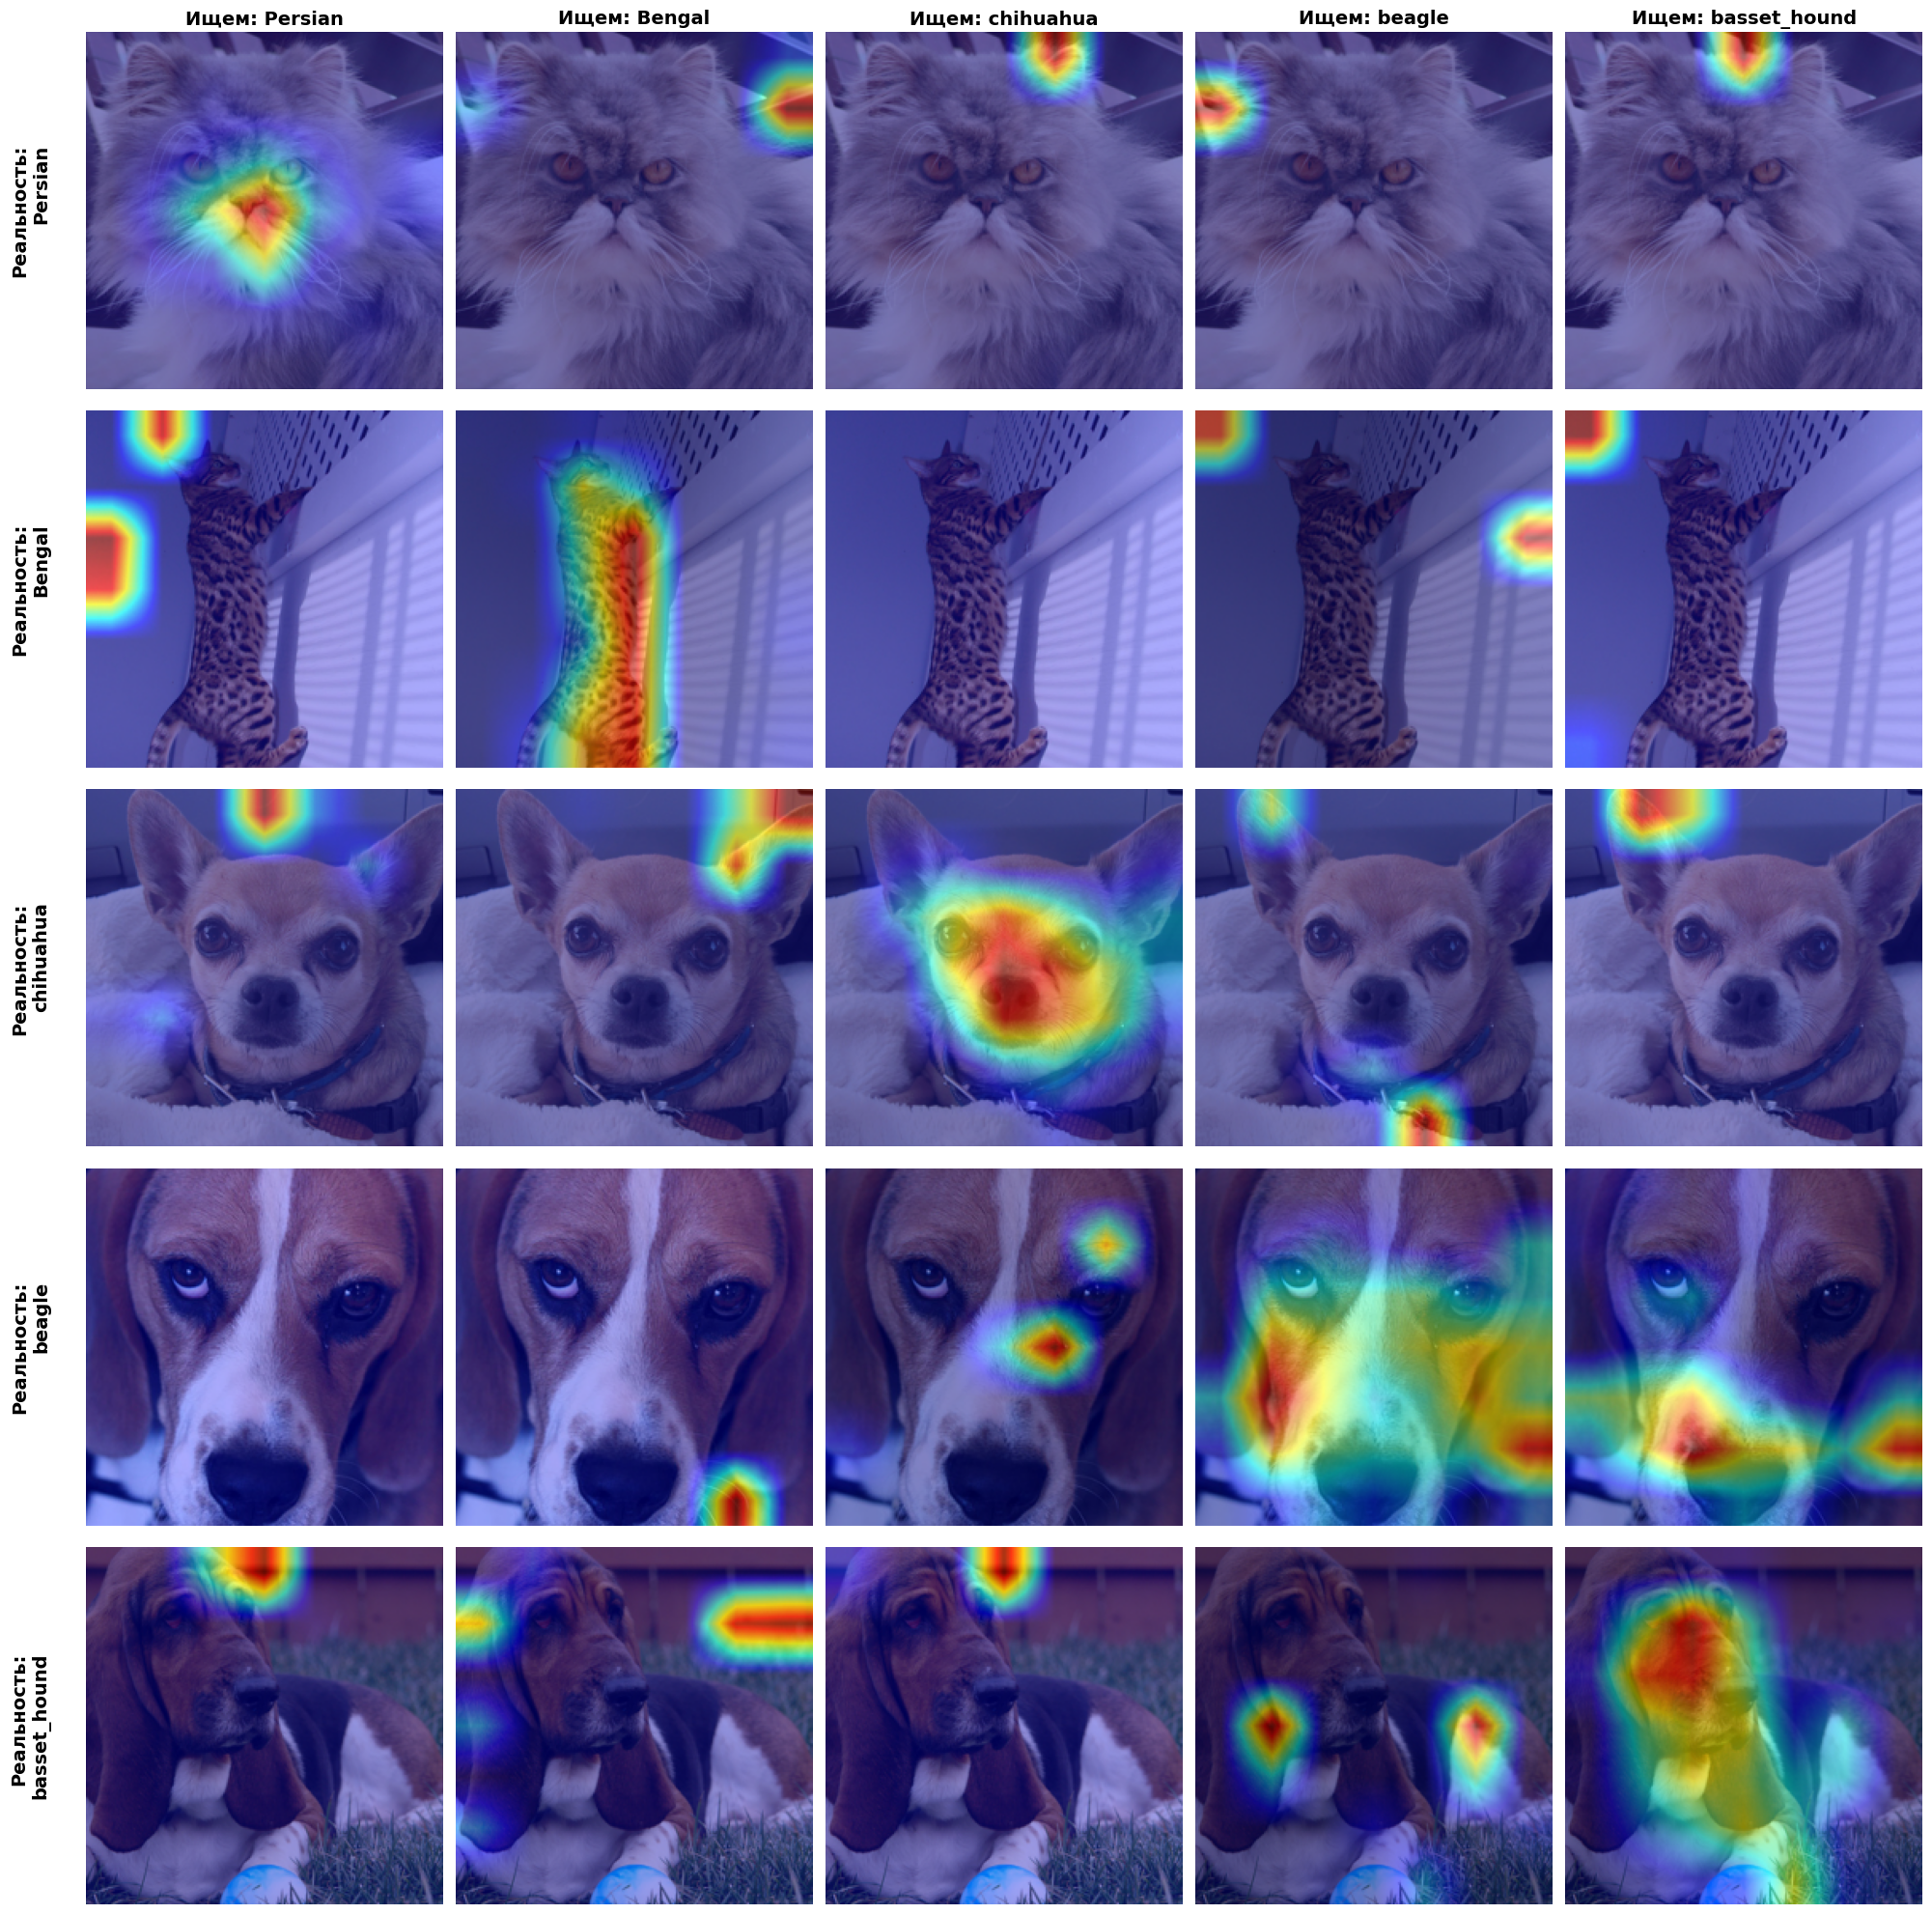

In [30]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


for param in model_resnet.parameters():
    param.requires_grad = True


# Функция для обратной нормализации картинки
def unnormalize(tensor):
    # Те самые mean и std от ImageNet, которые мы использовали вначале
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Переводим из формата PyTorch в формат картинки (канал в конце)
    img = tensor.permute(1, 2, 0).cpu().numpy()
    # Умножаем на std и прибавляем mean
    img = std * img + mean
    # Обрезаем значения, чтобы они не вышли за пределы [0, 1]
    img = np.clip(img, 0, 1)
    return img

# Выбираем 5 случайных классов
random.seed(42)
selected_classes_idx = random.sample(range(37), 5)
selected_classes_names = [idx_to_class[i] for i in selected_classes_idx]

print(f"Выбранные классы для анализа: {selected_classes_names}")

# Находим по одной картинке для каждого выбранного класса из тестового датасета
images_to_test =[]
for cls_idx in selected_classes_idx:
    for img, label in test_dataset:
        if label == cls_idx:
            images_to_test.append(img)
            break

# Настраиваем Grad-CAM
# Для ResNet-50 последним сверточным слоем является model.layer4[-1]
target_layers = [model_resnet.layer4[-1]]
cam = GradCAM(model=model_resnet, target_layers=target_layers)

fig, axes = plt.subplots(5, 5, figsize=(20, 20))

model_resnet.eval()

# Проходимся по строкам (картинкам)
for i in range(5):
    input_tensor = images_to_test[i].unsqueeze(0).to(device)
    rgb_img = unnormalize(images_to_test[i])
    true_class_name = selected_classes_names[i]

    # Проходимся по столбцам (целевым классам, которые мы ищем на картинке)
    for j in range(5):
        target_idx = selected_classes_idx[j]
        target_class_name = selected_classes_names[j]

        # Говорим Grad-CAM: "Построй карты активаций для класса target_idx"
        targets = [ClassifierOutputTarget(target_idx)]

        # Получаем тепловую карту (grayscale_cam)
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        # Накладываем тепловую карту на оригинальную картинку
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        # Отрисовка
        axes[i, j].imshow(visualization)
        axes[i, j].axis('off')

        # Подписи столбцов
        if i == 0:
            axes[i, j].set_title(f"Ищем: {target_class_name}", fontsize=14, color=color, fontweight='bold')

        # Подписи строк
        if j == 0:
            axes[i, j].text(-0.1, 0.5, f"Реальность:\n{true_class_name}",
                            fontsize=14, rotation=90, va='center', ha='right',
                            transform=axes[i, j].transAxes, fontweight='bold')

plt.tight_layout()
plt.show()

Неплохое выделение зон интереса модели!

Чуть проанализируем:
1. Persian: Модель четко фокусируется на «приплюснутой» мордочке и характерном носе — главных признаках персидской кошки.
2. Bengal: Карта активации подсвечивает все тело кошки, особенно паттерны пятен на шерсти. Это доказывает, что для определения этой породы сеть выучила именно уникальный окрас.
3. Chihuahua: Внимание сосредоточено на морде и области между глаз — ключевых анатомических чертах этой маленькой собаки.
4. Beagle и Basset Hound: Модель смотрит на морду и висячие уши. На последней строке (Basset Hound) ярко подсвечены именно длинные уши и характерные складки.


А когда наоборот, мы пытаемся найчи чужой класс, то происходит следуюшее:
1. Когда мы просим сеть найти «Chihuahua» на картинке с «Persian», она начинает искать похожие мелкие черты (например, кончики ушей или глаза), но активация получается менее уверенной или смещенной.
2. Часто «горячие точки» вне диагонали уходят на фон или края объекта, так как сеть не находит прямых подтверждений искомого класса и реагирует на случайные шумы, отдаленно напоминающие признаки другой породы.

Кажется, готово)